# Robot Anomaly Detection - Data Preparation

This notebook loads robot sensor data, creates differential features, and trains a multiclass anomaly detection model.

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Set the path to your .parquet file
parquet_path = '/content/drive/My Drive/Robot-Anomaly-Dataset/data.parquet'

Mounted at /content/drive


In [5]:
# Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Differential Feature Engineering
Creating new-features exempt from the dataset, which consist of the differences between adjacent data-points, to provide continous transformation information.

In [6]:
def create_diff_features(sub_features, df, features):
    """
    Create differential features between pairs of sensor measurements for each motor.

    This function computes the difference between each pair of features in sub_features
    for each motor and adds these differential features to the features dictionary.

    Args:
        sub_features (list): List of base feature names to create differences from
        df (DataFrame): DataFrame containing the original sensor data
        features (dict): Dictionary to store the created differential features

    Returns:
        None: Features are added to the provided features dictionary
    """
    motors = list(range(1, 7))  # Motors 1 through 6

    for i, f1 in enumerate(sub_features):
        for j in range(i + 1, len(sub_features)):
            f2 = sub_features[j]
            for motor in motors:
                motor_str = str(motor)
                feature_name = f"{f1}_diff_{f2}_{motor_str}"

                # Calculate difference between two measurements for this motor
                diff = np.subtract(
                    df[f"{f1}_{motor_str}"],
                    df[f"{f2}_{motor_str}"]
                )

                features[feature_name] = diff

## Load and Prepare Data
Extract .parquet data, and write it into a Pandas dataframe.

In [7]:
print("Loading robot sensor data...")
df = pd.read_parquet(parquet_path)

print(f"Dataset loaded with {len(df)} rows and {len(df.columns)} columns")
print("Available measurements:", ", ".join(sorted(list(set([col.split('_')[0] for col in df.columns if '_' in col])))))

features = {}

print("Generating differential features...")
create_diff_features(["motor_velocity", "joint_velocity", "target_velocity"], df, features)
create_diff_features(["motor_position", "joint_position", "target_position"], df, features)
create_diff_features(["motor_torque", "torque_sensor_a", "torque_sensor_b", "computed_torque"], df, features)

print("Adding categorical and system measurements...")
metadata_cols = ["category", "anomaly", "sample", "time"]
system_cols = ["system_current", "robot_voltage", "robot_current"]

for col in metadata_cols + system_cols:
    features[col] = df[col]

print("Adding motor current measurements...")
for i in range(1, 7):
    features[f"motor_iq_{i}"] = df[f"motor_iq_{i}"]
    features[f"motor_id_{i}"] = df[f"motor_id_{i}"]

print(f"Feature generation complete. Total features created: {len(features)}")
our_data = pd.DataFrame(features)

Loading robot sensor data...
Dataset loaded with 2321690 rows and 137 columns
Available measurements: brake, computed, io, joint, motor, power, robot, supply, system, target, torque
Generating differential features...
Adding categorical and system measurements...
Adding motor current measurements...
Feature generation complete. Total features created: 91


## Organize Samples by Category

In [8]:
def organize_samples_by_category(dataframe):
    """
    Organize time series samples into clean and anomaly categories.

    Args:
        dataframe (pd.DataFrame): DataFrame containing the features with sample and anomaly columns

    Returns:
        tuple: (samples, clean_samples, anomaly_samples) where:
               - samples is a list of all sample time series
               - clean_samples is a list of normal operation samples
               - anomaly_samples is a list of lists (by category) of anomalous samples
    """
    samples = []
    clean_samples = []
    anomaly_samples = [[] for _ in range(12)]  # 12 anomaly categories

    # Group data by sample ID
    for _, group in dataframe.groupby('sample'):
        samples.append(group)

    # Categorize samples as clean or by anomaly type
    for sample in samples:
        first_point = sample.iloc[0]
        if first_point["anomaly"]:
            anomaly_samples[first_point["category"]].append(sample)
        else:
            clean_samples.append(sample)

    return samples, clean_samples, anomaly_samples

samples, clean_samples, anomaly_samples = organize_samples_by_category(our_data)

print(f"Clean samples: {len(clean_samples)}")
for i in range(len(anomaly_samples)):
    if len(anomaly_samples[i]) > 0:
        print(f"Anomaly category {i}: {len(anomaly_samples[i])} samples")

clean_sample = clean_samples[3]
extra_friction_sample = anomaly_samples[0][3]  # Category 0 is "extra friction"

all_samples = {"clean": clean_samples, "anomalies": anomaly_samples}
with open('data.pkl', 'wb') as file:
    pickle.dump(all_samples, file)
    print("Sample data saved to data.pkl")

Clean samples: 1367
Anomaly category 0: 144 samples
Anomaly category 1: 156 samples
Anomaly category 2: 72 samples
Anomaly category 3: 48 samples
Anomaly category 4: 22 samples
Anomaly category 5: 11 samples
Anomaly category 6: 74 samples
Anomaly category 7: 80 samples
Anomaly category 8: 10 samples
Anomaly category 9: 12 samples
Anomaly category 10: 89 samples
Anomaly category 11: 37 samples
Sample data saved to data.pkl


## Feature Comparison Visualization


Generating feature comparison plots...


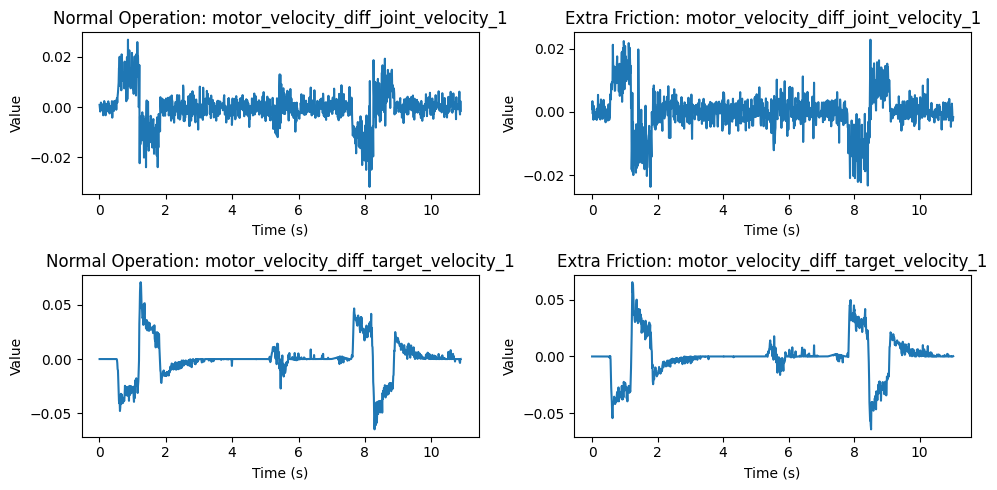

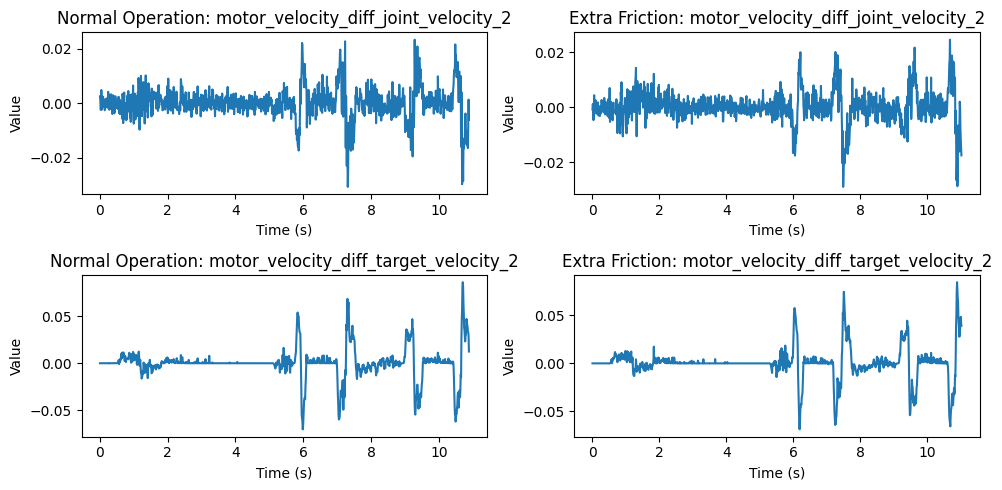

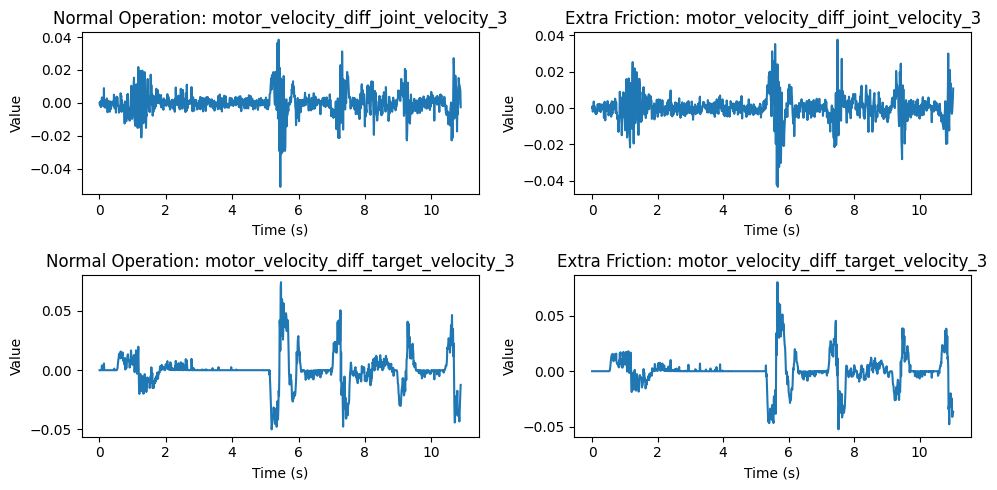

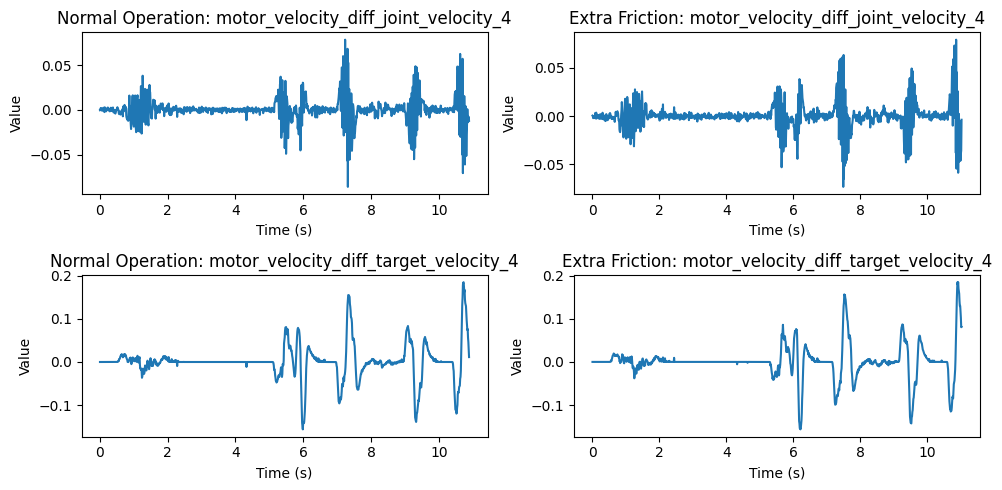

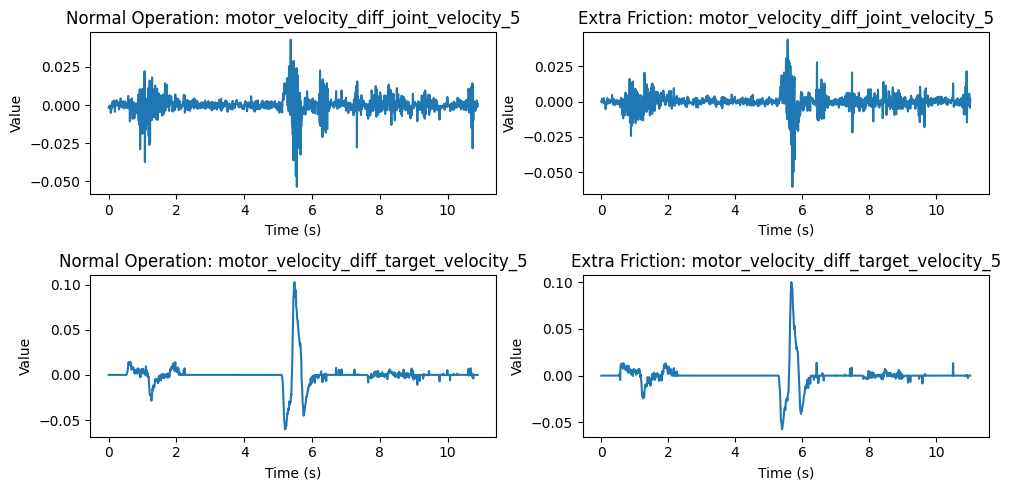

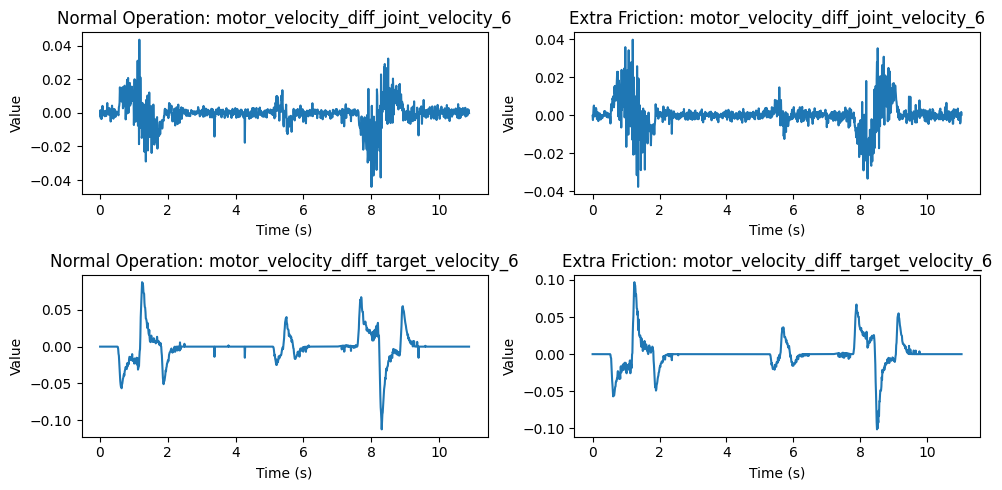

In [9]:
def plot_feature_comparison(clean_sample, anomaly_sample, motor_num, features_to_plot):
    """
    Plots a comparison of selected features between clean and anomalous samples.

    Args:
        clean_sample (pd.DataFrame): A time series of a normal operation
        anomaly_sample (pd.DataFrame): A time series of an anomalous operation
        motor_num (int): Motor number to examine
        features_to_plot (list): List of feature patterns to plot (motor number will be appended)

    Returns:
        plt.Figure: The matplotlib figure containing the plots
    """
    # Format feature names with motor number
    variables = [f"{feature}_{motor_num}" for feature in features_to_plot]
    num_vars = len(variables)

    # Create plot grid
    fig, axes = plt.subplots(num_vars, 2, figsize=(10, 2.5 * num_vars))

    # Create comparison plots
    for i, variable in enumerate(variables):
        # Clean sample plot
        axes[i, 0].plot(clean_sample["time"], clean_sample[variable])
        axes[i, 0].set_title(f"Normal Operation: {variable}")
        axes[i, 0].set_xlabel("Time (s)")
        axes[i, 0].set_ylabel("Value")

        # Anomaly sample plot
        axes[i, 1].plot(anomaly_sample["time"], anomaly_sample[variable])
        axes[i, 1].set_title(f"Extra Friction: {variable}")
        axes[i, 1].set_xlabel("Time (s)")
        axes[i, 1].set_ylabel("Value")

    plt.tight_layout()
    return fig

print("Generating feature comparison plots...")
for motor_num in range(1, 7):
    feature_patterns = [
        "motor_velocity_diff_joint_velocity",
        "motor_velocity_diff_target_velocity"
    ]
    plot_feature_comparison(
        clean_sample,
        extra_friction_sample,
        motor_num,
        feature_patterns
    )
    # plt.show()

## Data Preparation for Model Training

In [ ]:
print("Preparing data for model training...")

metadata_columns = ["category", "anomaly", "sample", "time"]
numeric_cols = [col for col in our_data.columns if col not in metadata_columns]

print("Standardizing numeric features...")
scaler = StandardScaler()
our_data[numeric_cols] = scaler.fit_transform(our_data[numeric_cols])
print("Standardization complete.")

MODEL_CONFIG = {
    "HIDDEN_LAYERS": 2,
    "NODES_PER_LAYER": 64
}

X = []
y = []

# Class index to name mapping
CLASS_LABELS = {
    0: "Normal",
    1: "Additional friction",
    2: "Add. axis weight",
    3: "Varying can weight",
    4: "Miscommutation",
    5: "Unstable platform"
}
# Mapping anomaly category index to label index in y
ANOMALY_CATEGORY_TO_LABEL = {
    0: 1,   # Additional friction
    1: 2,   # Add. axis weight
    7: 3,   # Varying can weight
    10: 4,  # Miscommutation
    11: 5   # Unstable platform
}

print("Preparing normal samples...")
for sample in clean_samples:
    X.append(sample.drop(columns=metadata_columns))
    y.append(np.zeros(len(sample), dtype=int))

for anomaly_cat, label in ANOMALY_CATEGORY_TO_LABEL.items():
    print(f"Preparing anomaly samples (category {anomaly_cat}: {CLASS_LABELS[label]})...")
    for sample in anomaly_samples[anomaly_cat]:
        X.append(sample.drop(columns=metadata_columns))
        y.append(np.full(len(sample), label, dtype=int))

X = pd.concat(X, ignore_index=True)
y = np.concatenate(y)

class_counts = [np.sum(y == i) for i in range(len(CLASS_LABELS))]
print(f"Dataset prepared: {X.shape[0]} samples with {X.shape[1]} features")
for i, name in CLASS_LABELS.items():
    print(f"{name}: {class_counts[i]} samples")

Preparing data for model training...
Standardizing numeric features...


## Model Training and Evaluation

In [ ]:
def train_anomaly_detection_model(X, y, model_params=None, save_path=None):
    """
    Train a multiclass anomaly detection model using a neural network.

    Args:
        X (pd.DataFrame): Feature dataset
        y (np.ndarray): Target labels (0: clean, 1: anomaly0, 2: anomaly1)
        model_params (dict, optional): Neural network hyperparameters
        save_path (str, optional): Path to save the trained model

    Returns:
        tuple: (trained_model, evaluation_metrics)
    """
    # Set default parameters if none provided
    if model_params is None:
        model_params = {
            'hidden_layer_sizes': (100, 50),
            'activation': 'relu',
            'solver': 'adam',
            'learning_rate_init': 0.001,
            'max_iter': 200,
            'random_state': 42,
            'verbose': True
        }

    # 1. Split the data with stratification to maintain class balance
    print("Splitting data into training and testing sets...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

    # 2. Create and train the neural network (multiclass)
    print("\nTraining neural network model...")
    print(f"Model architecture: {model_params['hidden_layer_sizes']} hidden layers")

    # Compute class weights to handle imbalance
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    # class_weight_dict = {i: w for i, w in zip(classes, class_weights)}

    mlp = MLPClassifier(**model_params) #, class_weight=class_weight_dict)
    mlp.fit(X_train, y_train)

    # 3. Evaluate the model
    print("\nEvaluating model performance...")
    y_pred = mlp.predict(X_test)

    # Calculate various metrics
    target_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(CLASS_LABELS))))

    # Collect metrics
    evaluation_metrics = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm,
        'y_test': y_test,
        'y_pred': y_pred
    }

    # 4. Save the model if a path is specified
    if save_path:
        joblib.dump(mlp, save_path)
        print(f"Model saved to {save_path}")

    return mlp, evaluation_metrics

## Confusion Matrix Visualization

In [ ]:
def plot_confusion_matrix(confusion_matrix_data, class_names=None):
    """
    Plot and format a confusion matrix visualization.

    Args:
        confusion_matrix_data (numpy.ndarray): The confusion matrix
        class_names (list): Names of the classes
    """
    if class_names is None:
        class_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_data,
                                  display_labels=class_names)

    disp.plot(cmap='Blues', values_format='d', ax=ax)

    # Add title and labels
    plt.title('Confusion Matrix', fontsize=15)
    plt.grid(False)

    # Add text with overall accuracy
    total = np.sum(confusion_matrix_data)
    correct = np.trace(confusion_matrix_data)
    accuracy = correct / total

    plt.figtext(0.5, 0.01, f'Overall Accuracy: {accuracy:.4f}',
                ha='center', fontsize=12)

    plt.tight_layout()
    return fig

## Learning Curve Visualization

In [ ]:
def plot_model_learning_curve(model, X, y, cv=5):
    """
    Plot learning curves for the trained model to diagnose overfitting/underfitting.

    Args:
        model: Trained model
        X: Features
        y: Target labels
        cv: Number of cross-validation folds
    """
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    # Calculate mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curve
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.grid()
    ax.fill_between(train_sizes, train_mean - train_std,
                    train_mean + train_std, alpha=0.1, color="r")
    ax.fill_between(train_sizes, test_mean - test_std,
                    test_mean + test_std, alpha=0.1, color="g")
    ax.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    ax.set_title("Learning Curve", fontsize=14)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Accuracy")
    ax.legend(loc="best")

    return fig

## Main Execution: Train and Evaluate Model

In [ ]:
model_config = {
    'hidden_layer_sizes': (100, 50),
    'activation': 'relu',
    'solver': 'adam',
    'learning_rate_init': 0.001,
    'max_iter': 2,
    'random_state': 47,
    'verbose': True,
    'early_stopping': True,
    'validation_fraction': 0.1
}

model_save_path = "robot_anomaly_detection_model.pkl"
model, metrics = train_anomaly_detection_model(
    X, y,
    model_params=model_config,
    save_path=model_save_path
)

print("\n----- Model Evaluation Results -----")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print("\nDetailed Classification Report:")
print(metrics['classification_report'])

print("\nConfusion Matrix:")
print(metrics['confusion_matrix'])

cm_fig = plot_confusion_matrix(metrics['confusion_matrix'], class_names=[CLASS_LABELS[i] for i in range(len(CLASS_LABELS))])
plt.figure(cm_fig.number)
plt.savefig('confusion_matrix.png')

lc_fig = plot_model_learning_curve(model, X, y)
plt.figure(lc_fig.number)
plt.savefig('learning_curve.png')

print("\nVisualizations saved as 'confusion_matrix.png' and 'learning_curve.png'")

# loaded_model = joblib.load(model_save_path)
# loaded_accuracy = accuracy_score(metrics['y_test'], loaded_model.predict(X_test))
# print(f"\nVerification - Loaded model accuracy: {loaded_accuracy:.4f}")

plt.show()

To install all dependencies listed in your `pyproject.toml` from the project folder, use the following command in your terminal:

In [ ]:
# In your terminal, from the project root (where pyproject.toml is located):
# For pip (using PEP 621/pyproject.toml support via pip >=23.1):
# !pip install .

# Or, if you use poetry (recommended for pyproject.toml management):
# !pip install poetry
# !poetry install